# Method B — Dynamic Meta-path Search 실험

> **목적**: 05 EDA가 정한 설계 prior(L=2, per-edge depth, 키워드 IDF 가중)를
> 실제 학습으로 검증·확정한다. baseline(methodA_relation_gating.ipynb, static relation-gating)과 분리.
>
> **근거 문서**: `docs/methodology_metapath_search.md` / EDA: `eda/notebooks/05_metapath_topology_eda.ipynb`
>
> | 실험 | IDF | L | 역할 |
> |---|---|---|---|
> | exp07 | off | 2 | baseline (현재 그래프, test-eval 버그 수정 후 재실행) |
> | exp08 | **on** | 2 | IDF 효과 (O2) |
> | exp09 | on | **3** | L-sweep (parsimony 규칙) |
> | exp10 | off | 2 | learned 1/2-hop readout: `H¹,H²` 가중합 성능 검증 |
> | exp11 | off | 1 | no-basket, learned_hop_sum L=1 |
> | exp12 | off | 2 | no-basket, learned_hop_sum L=2 |
> | exp13 | off | 3 | no-basket, learned_hop_sum L=3 |
>
> **parsimony 결정규칙**: L=3(exp09)이 L=2(exp08)를 시드별 noise(std) 넘는 마진으로
> 이겨야만 L=3 채택, 아니면 L=2. (L=3은 파라미터↑ 과적합 위험 + nnz 2.4배)

## 0. 환경 설정 (공통)

In [ ]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

_nb_file = globals().get('__vsc_ipynb_file__', None)
_anchor  = Path(_nb_file).resolve().parent if _nb_file else Path.cwd()
ROOT = None
for _p in [_anchor] + list(_anchor.parents):
    if (_p / "CLAUDE.md").exists():
        ROOT = str(_p); break
if ROOT is None:
    ROOT = str(_anchor)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from experiments.exp_utils import (
    run_experiment, load_experiment, compare_experiments,
    plot_alpha_heatmap, plot_training_curve, print_metrics_table, print_recommendations
)

# Method B 실험 config (methodA_relation_gating.ipynb와 동일 헬퍼 재사용)
CFG = {
    'exp07': 'experiments/configs/exp07_copurchase_binary.yaml',   # baseline (IDF off, L=2)
    'exp08': 'experiments/configs/exp08_idf_keyword.yaml',         # IDF on, L=2
    'exp09': 'experiments/configs/exp09_idf_L3.yaml',              # IDF on, L=3
    'exp10': 'experiments/configs/exp10_learned_hop_readout.yaml', # H¹/H² learned readout
    'exp11': 'experiments/configs/exp11_no_basket_L1_hop_readout.yaml',
    'exp12': 'experiments/configs/exp12_no_basket_L2_hop_readout.yaml',
    'exp13': 'experiments/configs/exp13_no_basket_L3_hop_readout.yaml',
    'exp14': 'experiments/configs/exp14_regularized.yaml',        # exp10+정규화
    'exp15': 'experiments/configs/exp15_pos_weight.yaml',         # exp10+pos_weight4.5
    'exp16': 'experiments/configs/exp16_hidden64.yaml',           # exp10+hidden64
    'exp18': 'experiments/configs/exp18_multihop_1attn.yaml',     # 멀티홉 1-어텐션 (제품공간 sim, 2홉 후보 최고)
    # --- exp18 기반 튜닝 + 2홉 임계 스윕 + 애블레이션 ---
    'exp19': 'experiments/configs/exp19_reg_on18.yaml',           # exp18+정규화
    'exp20': 'experiments/configs/exp20_posw_on18.yaml',          # exp18+pos_weight
    'exp21': 'experiments/configs/exp21_h64_on18.yaml',           # exp18+hidden64
    'exp22': 'experiments/configs/exp22_2hop_kw3.yaml',           # sim 임계 kw≥3 (조밀) ★최고 0.6852
    'exp23': 'experiments/configs/exp23_2hop_kw8.yaml',           # sim 임계 kw≥8 (희소)
    'exp24': 'experiments/configs/exp24_2hop_kw2.yaml',           # sim 임계 kw≥2 (⚠ OOM 위험)
    'exp25': 'experiments/configs/exp25_multihop_2layer.yaml',    # exp18 2층 스택 (깊이 검증)
    'exp27': 'experiments/configs/exp27_no_sim_1layer.yaml',      # sim 제거 1홉 (애블레이션, 퇴화 기준)
    'exp31': 'experiments/configs/exp31_2hop_kw3_ip1.yaml',       # exp22(kw≥3) + IP 임계 2→1 (커버리지↑)
}
print('ROOT:', ROOT)
for _k, _p in CFG.items():
    assert os.path.exists(_p), f"{_k} config 없음: {_p}"
print(f'config {len(CFG)}종 확인 완료')

## 1. 실험 실행

각 셀은 `run_experiment` → 학습 → 평가 → 결과 저장(`experiments/results/{name}/`). GPU 권장.

In [17]:
r07 = run_experiment(CFG['exp07'], 'exp07_copurchase_binary')
print_metrics_table(r07)

[exp07_copurchase_binary] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8319    0.9508    0.7994     0.3780
val        0.7117    0.8497    0.6429     0.8313
test       0.6572    0.8518    0.6508     0.5181

[random]   0.2360


In [18]:
r08 = run_experiment(CFG['exp08'], 'exp08_idf_keyword')
print_metrics_table(r08)

[exp08_idf_keyword] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7939    0.9448    0.7891     0.6028
val        0.7222    0.8647    0.6740     0.7936
test       0.6718    0.8677    0.6512     0.8929

[random]   0.2360


In [19]:
r09 = run_experiment(CFG['exp09'], 'exp09_idf_L3')
print_metrics_table(r09)

[exp09_idf_L3] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8315    0.9520    0.8047     0.4989
val        0.7192    0.8533    0.6686     0.8466
test       0.6665    0.8584    0.6525     0.8197

[random]   0.2360


### exp10 — Learned 1/2-hop Influence Readout

exp07과 동일한 그래프/HP에서 classifier 입력만 `H²` 단독이 아니라 `softmax(β₁,β₂)·[H¹,H²]` 가중합으로 바꾼다.  
목적은 `S = λ₁·A_learned¹ + λ₂·A_learned²` 아이디어가 성공확률 예측 성능에서도 baseline을 이기는지 검증하는 것이다.

In [20]:
r10 = run_experiment(CFG['exp10'], 'exp10_learned_hop_readout')
print_metrics_table(r10)

[exp10_learned_hop_readout] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8096    0.9480    0.7912     0.6449
val        0.7428    0.8654    0.6800     0.8317
test       0.6777    0.8621    0.6685     0.8436

[random]   0.2360


### exp11~13 — No-basket L-sweep with Learned Hop Readout

동반구매 엣지(`co_offline`, `co_quick`)가 지배적인 shortcut인지 확인하기 위해 제거한 그래프에서 L=1/2/3을 다시 비교한다.  
단, 모든 실험은 exp10과 동일하게 `readout_hop_mode=learned_hop_sum`으로 고정해 readout 차이를 통제한다.

In [21]:
r11 = run_experiment(CFG['exp11'], 'exp11_no_basket_L1_hop_readout')
print_metrics_table(r11)

[exp11_no_basket_L1_hop_readout] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8405    0.9551    0.8016     0.5272
val        0.5877    0.8084    0.5808     0.4797
test       0.5770    0.8233    0.6187     0.4132

[random]   0.2360


In [22]:
r12 = run_experiment(CFG['exp12'], 'exp12_no_basket_L2_hop_readout')
print_metrics_table(r12)

[exp12_no_basket_L2_hop_readout] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7695    0.9321    0.7547     0.3657
val        0.5908    0.8048    0.5721     0.4237
test       0.5872    0.8199    0.5966     0.1429

[random]   0.2360


In [23]:
r13 = run_experiment(CFG['exp13'], 'exp13_no_basket_L3_hop_readout')
print_metrics_table(r13)

[exp13_no_basket_L3_hop_readout] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7478    0.9184    0.7198     0.7180
val        0.5918    0.8159    0.5904     0.7031
test       0.6136    0.8275    0.5967     0.6706

[random]   0.2360


### exp14~16 — exp10 튜닝 (정규화·pos_weight·용량)

In [24]:
r14 = run_experiment(CFG['exp14'], 'exp14_regularized'); print_metrics_table(r14)
r15 = run_experiment(CFG['exp15'], 'exp15_pos_weight'); print_metrics_table(r15)
r16 = run_experiment(CFG['exp16'], 'exp16_hidden64'); print_metrics_table(r16)

[exp14_regularized] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7952    0.9373    0.7453     0.7151
val        0.7453    0.8611    0.6706     0.8320
test       0.6473    0.8601    0.6313     0.8360

[random]   0.2360
[exp15_pos_weight] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8595    0.9648    0.8393     0.8595
val        0.7332    0.8567    0.6630     0.9187
test       0.6676    0.8547    0.6425     0.9305

[random]   0.2360
[exp16_hidden64] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8603    0.9648    0.8465     0.6313
val        0.7289    0.8643    0.6747     0.8762
test       0.6703    0.8589    0.6541     0.8436

[r

### exp18 — 멀티홉 1-어텐션 (가중합→어텐션→스코어)

In [25]:
r18 = run_experiment(CFG['exp18'], 'exp18_multihop_1attn'); print_metrics_table(r18)

[exp18_multihop_1attn] 그래프 동일 → 기존 체크포인트 export (재학습 건너뜀, force=True로 강제 가능).

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8236    0.9488    0.7918     0.7288
val        0.7394    0.8643    0.6667     0.8300
test       0.6815    0.8664    0.6724     0.8559

[random]   0.2360


### exp19~27 — exp18 기반 튜닝·2홉 임계 스윕·깊이/애블레이션

exp18(멀티홉 1-어텐션, 제품공간 sim)을 기준으로:
- **exp19~21**: 정규화·pos_weight·hidden64 튜닝
- **exp22~24**: sim 엣지 2홉 임계 스윕 (kw≥3 조밀 / kw≥8 희소 / kw≥2 ⚠OOM 위험)
- **exp25**: 2층 스택 (깊이 더 쌓으면? → 손해 검증)
- **exp27**: sim 제거 1홉 (애블레이션 — PR-AUC 최고지만 추천 순회 불가 = **퇴화 기준점**)

> 각 실험은 try/except로 감싸 OOM·오류 시 건너뜀 (Run All 안전).

In [ ]:
# exp19~31 일괄 실행 (OOM·오류 시 건너뜀)
_multihop = {
    'exp19': 'exp19_reg_on18', 'exp20': 'exp20_posw_on18', 'exp21': 'exp21_h64_on18',
    'exp22': 'exp22_2hop_kw3', 'exp23': 'exp23_2hop_kw8', 'exp24': 'exp24_2hop_kw2',
    'exp25': 'exp25_multihop_2layer', 'exp27': 'exp27_no_sim_1layer',
    'exp31': 'exp31_2hop_kw3_ip1',   # ★ exp22(kw≥3) + IP 임계 2→1 — 최종 후보 튜닝
}
_R = {}
for _key, _name in _multihop.items():
    try:
        _R[_name] = run_experiment(CFG[_key], _name)
        _m = _R[_name]['metrics']['test']
        print(f"  {_name:26s} test PR-AUC={_m['pr_auc']:.4f}  AUC={_m['auc_roc']:.4f}")
    except Exception as _e:
        print(f"  {_name:26s} → 건너뜀 ({type(_e).__name__}: {str(_e)[:60]})")
        import torch; torch.cuda.empty_cache() if torch.cuda.is_available() else None

# exp22 vs exp31 직접 대조 (sim_ip 임계 2 vs 1)
if 'exp22_2hop_kw3' in _R and 'exp31_2hop_kw3_ip1' in _R:
    _a = _R['exp22_2hop_kw3']['metrics']['test']['pr_auc']
    _b = _R['exp31_2hop_kw3_ip1']['metrics']['test']['pr_auc']
    print(f"\n  [exp22(ip≥2) vs exp31(ip≥1)] {_a:.4f} vs {_b:.4f}  Δ={_b-_a:+.4f}  → "
          + ("exp31(ip≥1) 우세" if _b-_a > 0.003 else "exp22(ip≥2) 우세" if _b-_a < -0.003 else "사실상 동률"))

## 2. 결과 비교 — IDF 효과 & L-sweep

In [ ]:
# 전체 실험 지표 비교 (train/val/test) — 저장된 결과 기준
_compare_names = [
    'exp07_copurchase_binary', 'exp08_idf_keyword', 'exp09_idf_L3',
    'exp10_learned_hop_readout',
    'exp11_no_basket_L1_hop_readout', 'exp12_no_basket_L2_hop_readout', 'exp13_no_basket_L3_hop_readout',
    'exp14_regularized', 'exp15_pos_weight', 'exp16_hidden64',
    'exp18_multihop_1attn',
    'exp19_reg_on18', 'exp20_posw_on18', 'exp21_h64_on18',
    'exp22_2hop_kw3', 'exp23_2hop_kw8', 'exp24_2hop_kw2',
    'exp25_multihop_2layer', 'exp27_no_sim_1layer', 'exp31_2hop_kw3_ip1',
]
# 결과 폴더가 있는 것만 비교 (건너뛴 실험 제외)
_avail = [n for n in _compare_names if os.path.exists(f'experiments/results/{n}')]
df = compare_experiments(_avail).sort_values('test_pr_auc', ascending=False)
try:
    from IPython.display import display; display(df)
except Exception:
    print(df.to_string())

## 3. 층별 관계 중요도 α_r (relation-specific depth 학습 확인)

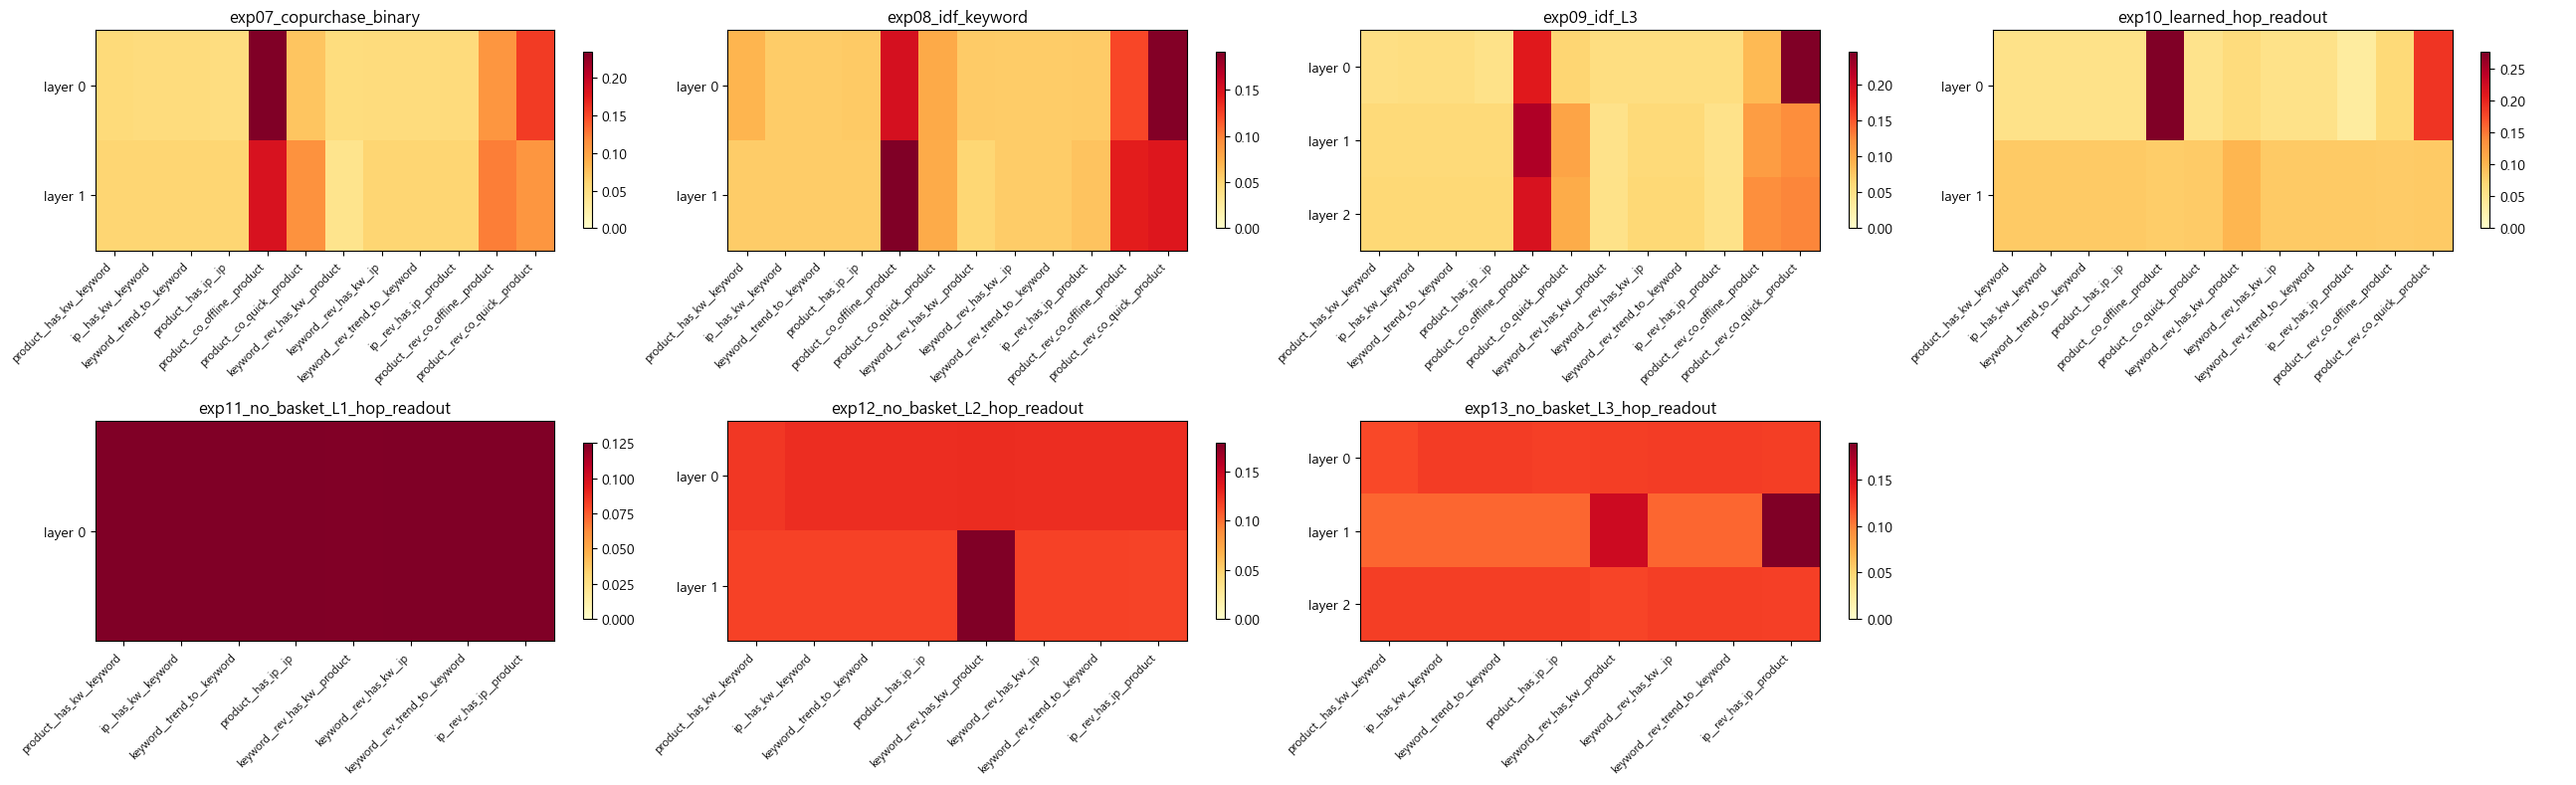

In [28]:
# 층별 DiffMG α_r 히트맵 — relation-specific depth가 학습됐는지 확인
# (basket이 layer-2에서 낮아지면 EDA의 per-edge L(basket=1)과 일치)
fig, axes = plt.subplots(2, 4, figsize=(26, 8))
axes = axes.ravel()
names = [
    'exp07_copurchase_binary',
    'exp08_idf_keyword',
    'exp09_idf_L3',
    'exp10_learned_hop_readout',
    'exp11_no_basket_L1_hop_readout',
    'exp12_no_basket_L2_hop_readout',
    'exp13_no_basket_L3_hop_readout',
]
for ax, name in zip(axes, names):
    try:
        plot_alpha_heatmap(name, ax=ax); ax.set_title(name)
    except Exception as e:
        ax.set_title(f'{name}\n(결과 없음: 먼저 실행)'); ax.text(0.5, 0.5, str(e)[:40], ha='center')
for ax in axes[len(names):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. K-P-K 추천 (꿀조합) — 최종 산출물 sanity check

In [29]:
# K-P-K 추천 (꿀조합) — exp10이 성능을 이기면 이후 최종 influence readout 후보로 사용
print('=== exp07 baseline ===')
print_recommendations(r07)
print('\n=== exp10 learned hop readout ===')
print_recommendations(r10)
print('\n=== exp12 no-basket L2 learned hop readout ===')
print_recommendations(r12)

=== exp07 baseline ===
  마라 → 도쿠시마(0.0415), 향라(0.0391), 탄탄(0.0379), 짜파게티(0.0132), 적음(0.0126), 샹궈(0.0119), 피(0.0116), 마라탕(0.0077), 곤약(0.0072), 자극적(0.0066)
  로제 → 떡볶퀸(0.0176), 늘어남(0.0165), 마카로니(0.0110), 하트(0.0042), 앙리(0.0042), 고단백(0.0035), 당면(0.0031), 중독성(0.0029), 누들(0.0027), 토핑(0.0021)
  흑임자 → 공룡(0.0189), 알(0.0081), 마카롱(0.0025), 묵직함(0.0018), 컵(0.0008), KBO(0.0008), 바나나(0.0007), 시루떡(0.0006), 케이크(0.0004), 롱롱이(0.0004)
  단백질 → 헬스(0.0092), 동물(0.0091), 엽떡(0.0090), 편함(0.0085), 이지프로틴(0.0068), 아르기닌(0.0068), 베노프(0.0064), 테이크핏(0.0044), 소이조이(0.0040), 피쉬(0.0032)
  위스키 → 블랙서클(0.0064), 산토리(0.0060), 티처스위스키(0.0060), 예술(0.0059), 맥캘란(0.0053), 메이커스마크(0.0044), 후드티(0.0041), 스트레이트(0.0029), 스프레드(0.0028), 캐리비안(0.0027)
  딸기 → 분홍(0.0043), 몽쉘(0.0041), 4D(0.0040), 돌직구(0.0040), 쿠냥이(0.0039), 고칸(0.0039), 데이(0.0027), 톡핑(0.0024), 쌍둥이(0.0022), 배트(0.0021)

=== exp10 learned hop readout ===
  마라 → 도쿠시마(0.0416), 향라(0.0402), 탄탄(0.0394), 박은영(0.0190), 샹궈(0.0165), 중독성(0.0154), 피(0.0136), 짜파게티(0.0135), 적음(0.0131), 마라탕(0.0093)
  

## 5. 결정 가이드

1. **IDF 효과**: exp07 vs exp08 의 test PR-AUC. 동등 이상이면 IDF 채택 (노이즈↓·해석력↑).
2. **L-sweep (parsimony)**: exp08(L2) vs exp09(L3).
   - L3가 L2를 **시드별 std 넘는 마진**으로 이기면 → L=3, 아니면 → **L=2**.
   - 시드 robust 비교가 필요하면 `run_experiment(..., overrides={"split.seed": s})`로 seed 3~5개 반복.
3. **Learned 1/2-hop readout**: exp10이 exp07을 test PR-AUC에서 이기면 `1-hop + 2-hop 영향력 가중합` 방향 채택. 못 이기면 최종 readout 후보에서 제외.
4. **No-basket L-sweep**: exp11~13은 모두 learned_hop_sum으로 고정. 동반구매 shortcut 제거 후에도 exp12(L=2)가 최선이면 L=2 prior 강화, exp13(L=3)이 noise margin 이상 이기면 no-basket 전용 L 재검토.
5. **α_r 히트맵**: basket(co_offline/co_quick)이 layer-2에서 낮으면 EDA per-edge L(basket=1)과 일치 — XAI 근거.
6. 확정 후 best 모델에 대해서만 전역/block influence map을 추출해 키워드 조합 + 상품/IP 근거 추천 리포트 생성.

## 6. dense A² 2홉 실험 (exp28 제품공간 + exp29 전체망 + 변형)

> **배경**: PR-AUC만 보면 1홉(exp27 0.691)이 이기지만, 1홉 모델은 추천 순회(K-P-K)를 못 하므로 **퇴화**다. 목적상 **2홉 영향**이 필수.
> 기존 2홉 후보(exp18/22 sim)는 **제품공간(P-K-P/P-I-P)** 만 봤고 K-K(트렌드)·I-K를 누락 → 전체 네트워크로 확장해 검증.
>
> **이 셀에 통합된 실험** (config로 표현 안 되는 커스텀 dense 모델 — `experiments/fullnet_dense_compare.py`):
> - **6a. exp28** — 제품공간(P×P) dense A² (직접 P-K 어텐션 누락 → 성능 낮음, 참고용)
> - **6b. exp29** — 전체망(N×N) dense A² base (`base(exp29)` 행)
> - **6c. 8변형** — 전체망 정규화(max/sym/row)·hop(1홉/2홉/합)·hidden·잔차 스윕
>
> **확정 방식**: dense 무임계 A² (`M=w₁A+w₂A²` → 공유 어텐션 → Hadamard). 임계컷 없음.
>
> 기준점: exp18(제품공간 sim) 0.6815 / exp10(전체망 스택) 0.678 / exp27(1홉, 퇴화) 0.691
>
> | 레버 | 후보 |
> |---|---|
> | 정규화 | `max`(전역최대) / `sym`(D^-1/2AD^-1/2, 허브 down-weight) / `row`(행정규화) |
> | hop | `sum`(w₁A+w₂A² 학습) / `a_only`(1홉) / `a2_only`(2홉) |
> | 용량 | hidden 128/64, 잔차 on/off |

In [30]:
# dense A² 2홉 실험 일괄 (exp28 제품공간 + exp29 전체망 base + 8변형)
# 무거운 모델/학습 코드는 experiments/fullnet_dense_compare.py 에 있음 (config로 표현 안 되는 커스텀 모델).
import torch, pandas as pd
from src.data_builder.build_hetero_data import build_graph
from experiments.fullnet_dense_compare import run_variant, run_product_space, VARIANTS, SEED

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data, _ = build_graph(seed=SEED, include_offline_copurchase=True, include_quick_copurchase=True,
                      use_lift_weights=False, add_2hop_edges=False)
P = data["product"].num_nodes; K = data["keyword"].num_nodes; I = data["ip"].num_nodes
print(f"P={P} K={K} I={I} | 전체망 N={P+K+I} | dense A²는 임계컷 없음\n")

rows = []
# 6a. exp28 — 제품공간(P×P) dense A²
try:
    r28 = run_product_space(data, P, K, I, dev); rows.append(r28)
    print(f"  [6a] {r28['name']:20s} test_pr={r28['test_pr']} auc={r28['test_auc']} peak={r28['peakGB']}GB")
except torch.cuda.OutOfMemoryError:
    print("  [6a] exp28 제품공간 → OOM"); torch.cuda.empty_cache()

# 6b+6c. exp29(전체망 base) + 8변형 — VARIANTS[0]='base(exp29)'가 곧 exp29
print("  [6b/6c] 전체망 dense 변형 (base(exp29) 포함):")
for cfg in VARIANTS:
    try:
        r = run_variant(data=data, P=P, K=K, I=I, dev=dev, **cfg); rows.append(r)
        tag = " ← exp29" if cfg['name'].startswith('base') else ""
        print(f"        {r['name']:16s} norm={r['norm']:3s} hop={r['hop']:7s} h={r['hid']} "
              f"| test_pr={r['test_pr']} auc={r['test_auc']} peak={r['peakGB']}GB{tag}")
    except torch.cuda.OutOfMemoryError:
        print(f"        {cfg['name']:16s} → OOM"); torch.cuda.empty_cache()

df_dense = pd.DataFrame(rows).sort_values("test_pr", ascending=False).reset_index(drop=True)
print("\n[참고] exp18 제품공간 sim 0.6815 / exp10 전체망 스택 0.678 / exp27 1홉(퇴화) 0.691")
try:
    from IPython.display import display; display(df_dense)
except Exception:
    print(df_dense.to_string())

P=5033 K=2598 I=281 | 전체망 N=7912 | dense A²는 임계컷 없음

  [6a] exp28_제품공간dense      test_pr=0.578 auc=0.8155 peak=3.18GB
  [6b/6c] 전체망 dense 변형 (base(exp29) 포함):
        base(exp29)      norm=max hop=sum     h=128 | test_pr=0.6233 auc=0.8259 peak=7.81GB ← exp29
        sym_norm         norm=sym hop=sum     h=128 | test_pr=0.6115 auc=0.8368 peak=7.81GB
        row_norm         norm=row hop=sum     h=128 | test_pr=0.6405 auc=0.8542 peak=7.81GB
        sym+1hop         norm=sym hop=a_only  h=128 | test_pr=0.679 auc=0.8704 peak=7.56GB
        sym+2hop         norm=sym hop=a2_only h=128 | test_pr=0.6592 auc=0.8549 peak=7.56GB
        sym+h64          norm=sym hop=sum     h=64 | test_pr=0.6114 auc=0.8321 peak=7.8GB
        sym+no_resid     norm=sym hop=sum     h=128 | test_pr=0.5775 auc=0.8224 peak=7.81GB
        row+h64          norm=row hop=sum     h=64 | test_pr=0.6485 auc=0.8522 peak=7.8GB

[참고] exp18 제품공간 sim 0.6815 / exp10 전체망 스택 0.678 / exp27 1홉(퇴화) 0.691


,name,test_pr,test_auc,val_pr,hopw,peakGB,norm,hop,hid,heads,residual,epochs
0,sym+1hop,0.6790,0.8704,0.7179,None,7.56,sym,a_only,128.0,4.0,True,45.0
1,sym+2hop,0.6592,0.8549,0.7099,None,7.56,sym,a2_only,128.0,4.0,True,78.0
2,row+h64,0.6485,0.8522,0.6761,"[0.528, 0.472]",7.80,row,sum,64.0,4.0,True,57.0
3,row_norm,0.6405,0.8542,0.6742,"[0.528, 0.472]",7.81,row,sum,128.0,4.0,True,54.0
4,base(exp29),0.6233,0.8259,0.6635,"[0.54, 0.46]",7.81,max,sum,128.0,4.0,True,60.0
5,sym_norm,0.6115,0.8368,0.6085,"[0.529, 0.471]",7.81,sym,sum,128.0,4.0,True,50.0
6,sym+h64,0.6114,0.8321,0.6119,"[0.524, 0.476]",7.80,sym,sum,64.0,4.0,True,56.0
7,exp28_제품공간dense,0.5780,0.8155,0.5867,"[0.357, 0.643]",3.18,NaN,NaN,NaN,NaN,NaN,NaN
8,sym+no_resid,0.5775,0.8224,0.6228,"[0.54, 0.46]",7.81,sym,sum,128.0,4.0,False,56.0


## 7. exp30 — Semantic Fusion (정제 3중 행렬) vs exp18

> **설계 정제**: 5중 dense 행렬에서 전체 dense 2홉(`A_2hop_PK`, `A_2hop_PI`) 제거.
> 이유 — sim 엣지가 곧 **2홉의 유의미 부분집합**이라, 전체 dense 2홉은 (1) sim과 **공선성** (2) 거른 **노이즈 재유입** (3) 연산 폭증을 부른다.
>
> **3중 행렬** (전부 sym 정규화, K-K·I-K 제외):
> - $\hat{A}_{1hop\_all}$ = P-P(영수증) ∪ P-K ∪ P-I
> - $\hat{A}_{sim\_ip}$ = P-I-P 공유 ≥1 (IP는 1개도 강신호, 커버리지↑)
> - $\hat{A}_{sim\_kw}$ = P-K-P 공유 ≥5 (노이즈 차단)
>
> $M = g_1\hat{A}_{1hop} + g_2\hat{A}_{sim\_ip} + g_3\hat{A}_{sim\_kw}$ (DiffMG 게이트) → 공유 어텐션 ⊙ M → **1층** readout.
>
> **비교**: exp18(제품공간 sim) **0.6815** = 현재 최고 2홉 모델. 차이 = sim_ip ≥1(vs ≥2)·K-K/I-K 제외·전체망 공유어텐션.
>
> ⚠️ K-K·I-K 제외는 **제품라벨엔 최적**이나, 추천(K-P-K) readout엔 트렌드 전파가 필요(05 Phase 10) — 추천 단계에선 별도 고려.

In [31]:
# exp30 — Semantic Fusion (정제 3중 행렬) 실행 + exp18 비교
import torch
from experiments.fullnet_dense_compare import run_semantic_fusion, SEED
from src.data_builder.build_hetero_data import build_graph

if 'data' not in globals():
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data, _ = build_graph(seed=SEED, include_offline_copurchase=True, include_quick_copurchase=True,
                          use_lift_weights=False, add_2hop_edges=False)
    P = data["product"].num_nodes; K = data["keyword"].num_nodes; I = data["ip"].num_nodes

r30 = run_semantic_fusion(data, P, K, I, dev, sim_kw_thr=5, sim_ip_thr=1)
print("exp30 Semantic Fusion (3중 행렬):")
print(f"  test PR-AUC = {r30['test_pr']}   AUC = {r30['test_auc']}   peak = {r30['peakGB']}GB")
print(f"  게이트 가중(1hop/sim_ip/sim_kw) = {r30['gate(1hop/sim_ip/sim_kw)']}")
print(f"  엣지 수 nnz = {r30['nnz']}")
print(f"\n  [비교] exp18 제품공간 sim 0.6815 / exp27 1홉(퇴화) 0.691 / sym+1hop 전체망 0.679")
_delta = r30['test_pr'] - 0.6815
print(f"  exp30 vs exp18 : {'+' if _delta>=0 else ''}{_delta:.4f}  → "
      + ("exp30 우세" if _delta > 0.003 else "exp18 우세" if _delta < -0.003 else "사실상 동률(시드 노이즈)"))

ImportError: cannot import name 'run_semantic_fusion' from 'experiments.fullnet_dense_compare' (C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\experiments\fullnet_dense_compare.py)